In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [6]:

import pandas as pd

df = pd.read_csv("data/financial_fraud_detection_dataset.csv")

In [7]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [8]:
df.shape

(5000000, 18)

In [9]:
df.columns


Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               str    
 1   timestamp                    str    
 2   sender_account               str    
 3   receiver_account             str    
 4   amount                       float64
 5   transaction_type             str    
 6   merchant_category            str    
 7   location                     str    
 8   device_used                  str    
 9   is_fraud                     bool   
 10  fraud_type                   str    
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              str    
 16  ip_address                   str    
 17  device_hash                  str    
dtypes: bool(1), float64(4), int64(1), str(12)
memory usag

In [11]:
df.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


In [14]:
df.dtypes

transaction_id                     str
timestamp                          str
sender_account                     str
receiver_account                   str
amount                         float64
transaction_type                   str
merchant_category                  str
location                           str
device_used                        str
is_fraud                          bool
fraud_type                         str
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                    str
ip_address                         str
device_hash                        str
dtype: object

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

ValueError: time data "2023-07-06T21:04:01" doesn't match format "%Y-%m-%dT%H:%M:%S.%f". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [16]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")

In [17]:
df.dtypes

transaction_id                            str
timestamp                      datetime64[us]
sender_account                            str
receiver_account                          str
amount                                float64
transaction_type                          str
merchant_category                         str
location                                  str
device_used                               str
is_fraud                                 bool
fraud_type                                str
time_since_last_transaction           float64
spending_deviation_score              float64
velocity_score                          int64
geo_anomaly_score                     float64
payment_channel                           str
ip_address                                str
device_hash                               str
dtype: object

In [18]:
df["Year"] = df["timestamp"].dt.year

In [19]:
df["Month"] = df["timestamp"].dt.month_name()

In [20]:
df["Month_Number"] = df["timestamp"].dt.month

In [21]:
df["Day"] = df["timestamp"].dt.day

In [22]:
df["Weekday"] = df["timestamp"].dt.day_name()

In [23]:
df["Hour"] = df["timestamp"].dt.hour

In [24]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,geo_anomaly_score,payment_channel,ip_address,device_hash,Year,Month,Month_Number,Day,Weekday,Hour
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,...,0.22,card,13.101.214.112,D8536477,2023,August,8,22,Tuesday,9
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,...,0.96,ACH,172.52.47.194,D2622631,2023,August,8,4,Friday,1
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,...,0.89,card,185.98.35.23,D4823498,2023,May,5,12,Friday,11
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,...,0.37,wire_transfer,107.136.36.87,D9961380,2023,October,10,10,Tuesday,6
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,...,0.27,ACH,108.161.108.255,D7637601,2023,September,9,24,Sunday,8


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("data/financial_fraud_detection_dataset.csv")

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")

In [6]:
df["Year"] = df["timestamp"].dt.year
df["Month"] = df["timestamp"].dt.month_name()
df["Month_Number"] = df["timestamp"].dt.month
df["Day"] = df["timestamp"].dt.day
df["Weekday"] = df["timestamp"].dt.day_name()
df["Hour"] = df["timestamp"].dt.hour

In [7]:
df.to_csv("data/cleaned/financial_transactions_cleaned.csv", index=False)

In [8]:
df["amount"].describe()

count    5.000000e+06
mean     3.589343e+02
std      4.699333e+02
min      1.000000e-02
25%      2.657000e+01
50%      1.386700e+02
75%      5.038900e+02
max      3.520570e+03
Name: amount, dtype: float64

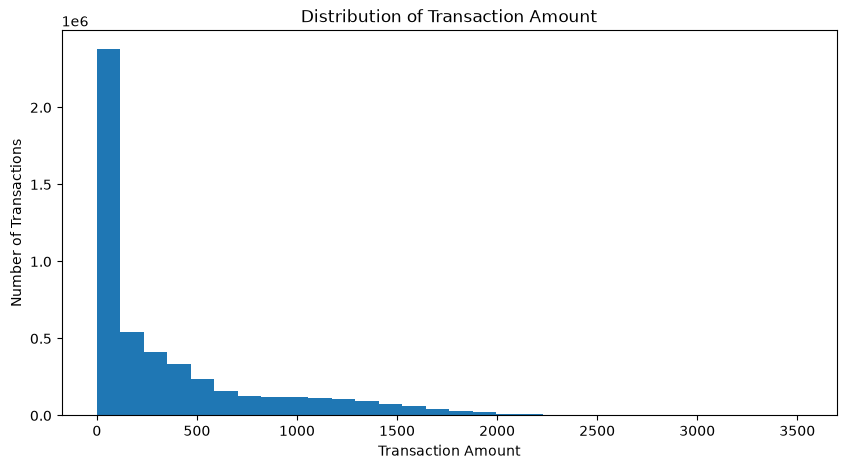

In [11]:
# How are transaction amounts distributed?
plt.figure(figsize=(10,5))
plt.hist(df["amount"], bins=30)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

In [12]:
#How many fraud transactions are there?
df["is_fraud"].value_counts()

is_fraud
False    4820447
True      179553
Name: count, dtype: int64

In [13]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
False    96.40894
True      3.59106
Name: proportion, dtype: float64

In [14]:
# Which payment channels are used the most?
df["payment_channel"].value_counts()

payment_channel
wire_transfer    1251219
ACH              1250241
card             1249693
UPI              1248847
Name: count, dtype: int64

In [15]:
# Which merchant category has the highest number of transactions?
df["merchant_category"].value_counts()

merchant_category
retail           626319
travel           625656
restaurant       625483
entertainment    625332
grocery          624954
other            624589
utilities        624086
online           623581
Name: count, dtype: int64

In [16]:
#Which cities have the highest transaction volume?
df["location"].value_counts()

location
Tokyo        625994
New York     625354
Singapore    625313
Berlin       625289
Sydney       625125
Toronto      624349
Dubai        624320
London       624256
Name: count, dtype: int64

# Financial Transaction Analytics

## Dataset Overview

- Total Transactions:5000000
- Total Features:18
- Missing Values:
  - fraud_type: 4,820,447
  - time_since_last_transaction: 896,513
- Duplicate Records:0
- Fraud Transactions:179,553
- Normal Transactions:4,820,447

## Key Observations

1. The dataset contains 5,000,000 financial transactions with 18 original features.
2. No duplicate records were found.
3. Most columns have no missing values, indicating high data quality.
4. The `fraud_type` column has missing values that are expected for non-fraudulent transactions.
5. The `timestamp` column was converted to datetime format for time-based analysis.